Saving gender_data.csv to gender_data (2).csv
Dataset Info:
Shape: (70, 3)
Columns: ['text', 'label', 'gender']

Label Distribution:
label
1    35
0    35
Name: count, dtype: int64

Gender Distribution:
gender
Male      35
Female    35
Name: count, dtype: int64

EVALUATING GENDER ATTRIBUTE

Evaluating Falcon on Bias Analysis dataset
Computing embeddings...
Training classifier...

Falcon Results:
Overall Accuracy: 0.6667
DPD (Bias): 0.3182
PAR (Fairness): 0.6111

Group-wise Accuracy:
 Group  Accuracy
Female  0.500000
  Male  0.818182

Evaluating BERT on Bias Analysis dataset
Computing embeddings...
Training classifier...

BERT Results:
Overall Accuracy: 0.7619
DPD (Bias): 0.0727
PAR (Fairness): 0.9091

Group-wise Accuracy:
 Group  Accuracy
Female  0.800000
  Male  0.727273

Evaluating GPT-2 on Bias Analysis dataset
Computing embeddings...
Training classifier...

GPT-2 Results:
Overall Accuracy: 0.7143
DPD (Bias): 0.2182
PAR (Fairness): 0.7333

Group-wise Accuracy:
 Group  Accuracy
Femal

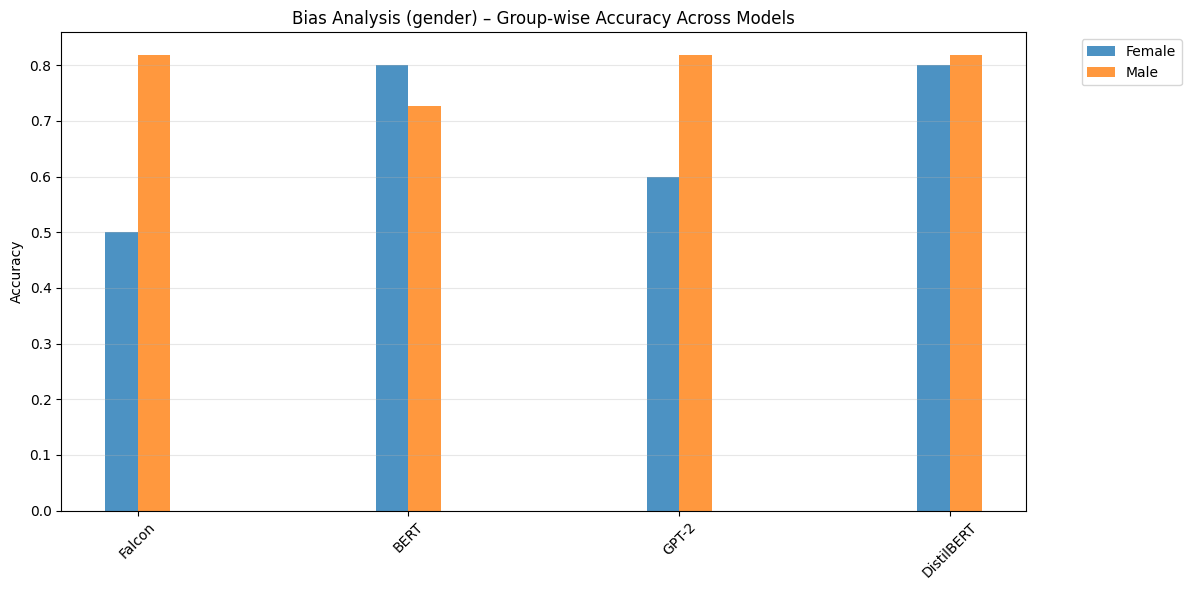

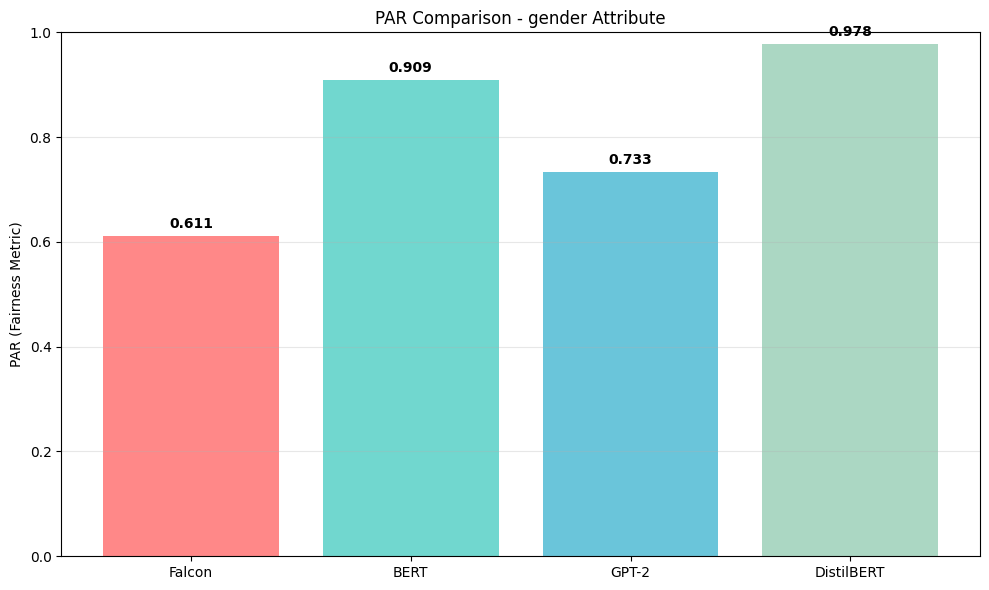

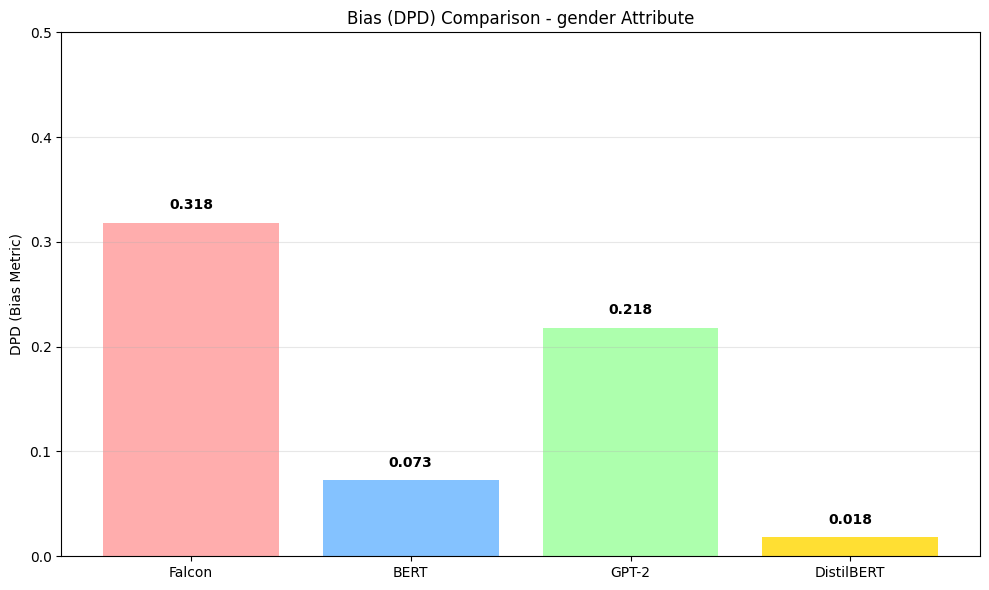

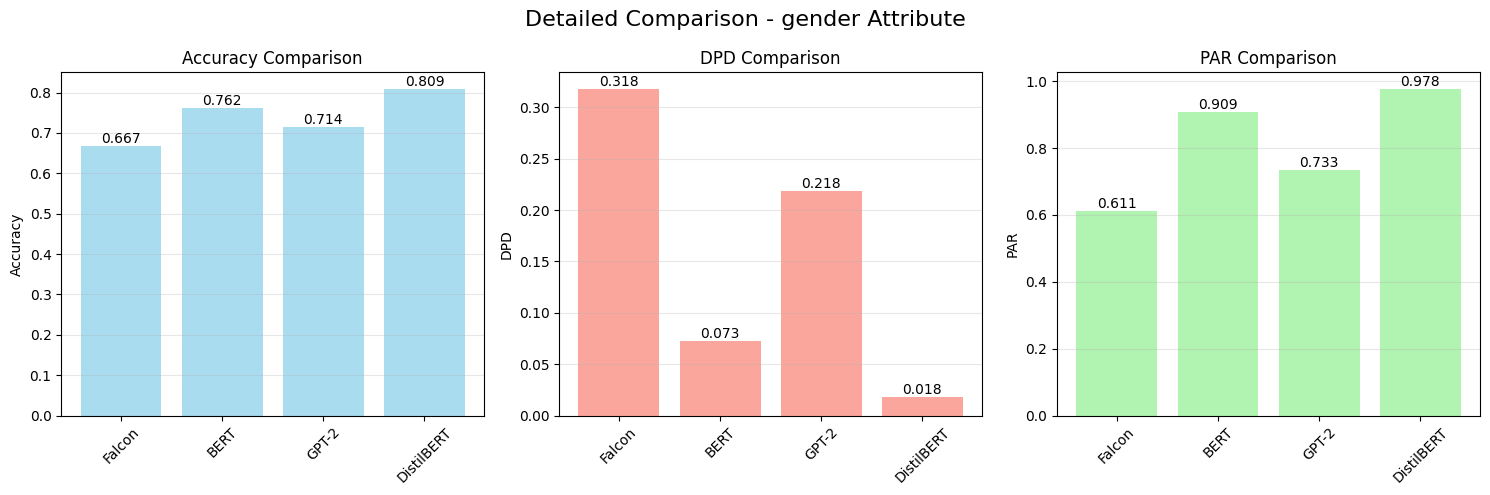


SUMMARY REPORT - GENDER ATTRIBUTE
Highest Accuracy: DistilBERT (0.8095)
Most Fair (Highest PAR): DistilBERT (0.9778)
Least Bias (Lowest DPD): DistilBERT (0.0182)

FINAL RESULTS SUMMARY
     Model  Accuracy    DPD    PAR
    Falcon    0.6667 0.3182 0.6111
      BERT    0.7619 0.0727 0.9091
     GPT-2    0.7143 0.2182 0.7333
DistilBERT    0.8095 0.0182 0.9778

✅ Detailed results saved to 'fairness_analysis_results.csv'

🎯 Evaluation Completed Successfully!


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# -------- Fairness Metrics --------
def group_metrics(y_true, y_pred, groups):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': groups})
    results = []
    for group, gdf in df.groupby('group'):
        acc = accuracy_score(gdf['y_true'], gdf['y_pred'])
        results.append({'Group': group, 'Accuracy': acc})
    result_df = pd.DataFrame(results)
    overall_acc = accuracy_score(y_true, y_pred)
    dpd = result_df['Accuracy'].max() - result_df['Accuracy'].min()
    par = result_df['Accuracy'].min() / result_df['Accuracy'].max() if result_df['Accuracy'].max() != 0 else 0
    return result_df, overall_acc, dpd, par

# -------- Batch Embeddings --------
def get_embeddings(model, tokenizer, texts, batch_size=16):
    model.to(device)
    embs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, padding=True, max_length=128)
        inputs = {k:v.to(device) for k,v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
            # Use pooler output if available, else mean pooling
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                batch_emb = outputs.pooler_output.cpu().numpy()
            else:
                batch_emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            embs.append(batch_emb)
    embs = np.vstack(embs)
    return embs

# -------- Plotting Functions --------
def plot_combined_fairness(all_results, dataset_name='Dataset'):
    plt.figure(figsize=(12, 6))

    # Get all unique groups from the first model's results
    groups = all_results[0][1]['Group'].tolist()
    x = np.arange(len(all_results))
    width = 0.12  # Reduced width for better spacing

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for i, group in enumerate(groups):
        vals = []
        for model_name, df in all_results:
            group_data = df[df['Group'] == group]
            if len(group_data) > 0:
                vals.append(group_data['Accuracy'].values[0])
            else:
                vals.append(0)  # Default value if group not found

        plt.bar(x + i*width, vals, width=width, label=group, color=colors[i % len(colors)], alpha=0.8)

    plt.xticks(x + width*(len(groups)-1)/2, [name for name, _ in all_results], rotation=45)
    plt.ylabel('Accuracy')
    plt.title(f'{dataset_name} – Group-wise Accuracy Across Models')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_par_comparison(model_results, title='PAR Comparison Across Models'):
    """Plot PAR values like in the screenshot"""
    models = [r['Model'] for r in model_results]
    par_vals = [r['PAR'] for r in model_results]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, par_vals, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8)

    plt.ylabel('PAR (Fairness Metric)')
    plt.title(title)
    plt.ylim(0, 1)

    # Add value labels on bars
    for bar, value in zip(bars, par_vals):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_model_bias_comparison(model_results, title='Model Bias Comparison (DPD)'):
    """Plot DPD values for bias comparison"""
    models = [r['Model'] for r in model_results]
    dpd_vals = [r['DPD'] for r in model_results]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, dpd_vals, color=['#FF9999', '#66B3FF', '#99FF99', '#FFD700'], alpha=0.8)

    plt.ylabel('DPD (Bias Metric)')
    plt.title(title)
    plt.ylim(0, 0.5)

    # Add value labels on bars
    for bar, value in zip(bars, dpd_vals):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_detailed_comparison(model_results, title='Detailed Model Comparison'):
    """Create a detailed comparison plot for all models and metrics"""
    models = [r['Model'] for r in model_results]
    metrics = ['Accuracy', 'DPD', 'PAR']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, metric in enumerate(metrics):
        values = [r[metric] for r in model_results]
        colors = ['skyblue' if metric == 'Accuracy' else
                 'salmon' if metric == 'DPD' else 'lightgreen']

        bars = axes[idx].bar(models, values, color=colors, alpha=0.7)
        axes[idx].set_title(f'{metric} Comparison')
        axes[idx].set_ylabel(metric)
        axes[idx].set_xticklabels(models, rotation=45)
        axes[idx].grid(axis='y', alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{value:.3f}', ha='center', va='bottom')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# -------- Evaluate Dataset --------
def evaluate_dataset(dataset_name, df, group_col, batch_size=16):
    # Models to test (using smaller models for faster execution)
    models_to_test = {
        'Falcon': 'tiiuae/falcon-rw-1b',
        'BERT': 'bert-base-uncased',
        'GPT-2': 'openai-community/gpt2',
        'DistilBERT': 'distilbert-base-uncased'
    }

    results = []
    all_model_fairness = []

    for model_label, model_name in models_to_test.items():
        print(f"\n{'='*60}")
        print(f"Evaluating {model_label} on {dataset_name} dataset")
        print(f"{'='*60}")

        try:
            # Load model and tokenizer
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)

            # Handle tokenizer padding
            if tokenizer.pad_token is None:
                if tokenizer.eos_token is not None:
                    tokenizer.pad_token = tokenizer.eos_token
                else:
                    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
                model.resize_token_embeddings(len(tokenizer))

            # Compute embeddings
            print("Computing embeddings...")
            X = get_embeddings(model, tokenizer, df['text'].tolist(), batch_size=batch_size)
            y = df['label'].values
            groups = df[group_col].values

            # Split data for proper evaluation
            X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
                X, y, groups, test_size=0.3, random_state=42, stratify=y
            )

            # Train classifier
            print("Training classifier...")
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            clf = LogisticRegression(max_iter=1000, random_state=42)
            clf.fit(X_train_scaled, y_train)
            preds = clf.predict(X_test_scaled)

            # Calculate fairness metrics on test set
            res, acc, dpd, par = group_metrics(y_test, preds, groups_test)

            print(f"\n{model_label} Results:")
            print(f"Overall Accuracy: {acc:.4f}")
            print(f"DPD (Bias): {dpd:.4f}")
            print(f"PAR (Fairness): {par:.4f}")
            print("\nGroup-wise Accuracy:")
            print(res.to_string(index=False))

            # Store results
            all_model_fairness.append((model_label, res))

            result_entry = {
                'Model': model_label,
                'Accuracy': round(acc, 4),
                'DPD': round(dpd, 4),
                'PAR': round(par, 4)
            }
            results.append(result_entry)

        except Exception as e:
            print(f"⚠️ Error evaluating {model_label}: {str(e)}")
            continue

    # Generate plots
    if all_model_fairness:
        plot_combined_fairness(all_model_fairness, f'{dataset_name} ({group_col})')
        plot_par_comparison(results, f'PAR Comparison - {group_col} Attribute')
        plot_model_bias_comparison(results, f'Bias (DPD) Comparison - {group_col} Attribute')
        plot_detailed_comparison(results, f'Detailed Comparison - {group_col} Attribute')

    return results

# -------- Generate Summary Report --------
def generate_summary_report(results, attribute_name):
    """Generate a comprehensive summary report"""
    summary_df = pd.DataFrame(results)

    print("\n" + "="*80)
    print(f"SUMMARY REPORT - {attribute_name.upper()} ATTRIBUTE")
    print("="*80)

    # Find best model for each metric
    best_acc = summary_df.loc[summary_df['Accuracy'].idxmax()]
    best_fair = summary_df.loc[summary_df['PAR'].idxmax()]
    least_bias = summary_df.loc[summary_df['DPD'].idxmin()]

    print(f"Highest Accuracy: {best_acc['Model']} ({best_acc['Accuracy']:.4f})")
    print(f"Most Fair (Highest PAR): {best_fair['Model']} ({best_fair['PAR']:.4f})")
    print(f"Least Bias (Lowest DPD): {least_bias['Model']} ({least_bias['DPD']:.4f})")

    return summary_df

# -------- Main Execution --------
def main():
    # Load dataset from Colab
    from google.colab import files
    uploaded = files.upload()
    csv_file = list(uploaded.keys())[0]
    data = pd.read_csv(csv_file)

    print("Dataset Info:")
    print(f"Shape: {data.shape}")
    print(f"Columns: {list(data.columns)}")
    print(f"\nLabel Distribution:")
    print(data['label'].value_counts())

    # Check available attributes
    available_attributes = []
    if 'marital' in data.columns:
        available_attributes.append('marital')
        print(f"\nMarital Status Distribution:")
        print(data['marital'].value_counts())
        print(f"Married positive rate: {data[data['marital']=='Married']['label'].mean():.2f}")
        print(f"Non-married positive rate: {data[data['marital']!='Married']['label'].mean():.2f}")

    if 'gender' in data.columns:
        available_attributes.append('gender')
        print(f"\nGender Distribution:")
        print(data['gender'].value_counts())

    # Evaluate available attributes
    all_results = []

    for attribute in available_attributes:
        print(f"\n{'='*80}")
        print(f"EVALUATING {attribute.upper()} ATTRIBUTE")
        print(f"{'='*80}")

        attribute_df = data[['text', 'label', attribute]].dropna()
        results = evaluate_dataset('Bias Analysis', attribute_df, attribute, batch_size=16)
        all_results.extend(results)

        # Generate summary for this attribute
        generate_summary_report(results, attribute)

    # Display final results
    if all_results:
        print("\n" + "="*80)
        print("FINAL RESULTS SUMMARY")
        print("="*80)
        final_df = pd.DataFrame(all_results)
        print(final_df.to_string(index=False))

        # Save results to CSV
        final_df.to_csv('fairness_analysis_results.csv', index=False)
        print(f"\n✅ Detailed results saved to 'fairness_analysis_results.csv'")

    print("\n🎯 Evaluation Completed Successfully!")

if __name__ == "__main__":
    main()